# NB21 — Paper Numbers Audit & Figure Index

**Purpose:** Single source-of-truth for all paper numbers. Run this after re-running NB8–NB20 to:
1. Update the hardcoded constants (§ "Hardcoded Results") with the latest experiment outputs
2. Verify every number claimed in the paper against actual notebook outputs
3. Regenerate summary figures for the paper body
4. Print the figure-location table (which notebook → which paper figure)

**No GPU required.** The only cells that need GPU are the figure regeneration cells (Figs 1–9), which are optional — the individual source notebooks already generated the authoritative figures.

**HOW TO UPDATE:** After re-running any experiment notebook, search for `=== FIGURE DATA ===` or `CONSOLIDATED RESULTS` in its output and copy the numbers into the constants cell below.

In [1]:
import torch, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import silhouette_score
import warnings, os, json
warnings.filterwarnings('ignore')

# ── Publication style (ACL 2-column) ──────────────────────────
SINGLE_COL = (3.5, 3.2)   # single column figure size
DOUBLE_COL = (7.0, 3.2)   # double column (full width)
WIDE_COL   = (7.0, 4.5)   # double column, taller

plt.rcParams.update({
    'font.size': 12, 'font.family': 'serif',
    'axes.titlesize': 12, 'axes.labelsize': 11,
    'xtick.labelsize': 10, 'ytick.labelsize': 10,
    'legend.fontsize': 9,
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.grid': True, 'grid.alpha': 0.25,
    'axes.spines.top': False, 'axes.spines.right': False,
})

TASK_COLORS = {
    'sentiment_analysis': '#E74C3C',
    'translate':          '#3498DB',
    'cryptanalysis':      '#F39C12',
    'rag_qa':             '#27AE60',
    'rephrase':           '#9B59B6',
}

os.makedirs('paper_figures', exist_ok=True)
print('✓ Setup complete')

✓ Setup complete


## 1. Load Embeddings & Canonical Masks

In [2]:
from google.colab import drive; drive.mount('/content/drive')
import os
os.makedirs('./embeddings', exist_ok=True)
os.makedirs('./arditi_artefacts', exist_ok=True)
!cp -a "/content/drive/MyDrive/embeddings/overalign_eval/llama/." ./embeddings/.
!cp -a /content/drive/MyDrive/Colab\ Notebooks/SteeringFail/arditi_artefacts/* arditi_artefacts/ 2>/dev/null || true

def convert_embeddings_to_numpy(d):
    out = {}
    for k, v in d.items():
        if isinstance(v, torch.Tensor):
            out[k] = v.float().numpy().astype(np.float32)
        else:
            out[k] = np.array([e.float().numpy().astype(np.float32) for e in v])
    return out

embeddings_dir = './embeddings/'
csv_path = sorted([os.path.join(embeddings_dir, f) for f in os.listdir(embeddings_dir) if f.endswith('.csv')])[-1]
csv_df   = pd.read_csv(csv_path)
torch_data = torch.load(csv_df['torch_path'].iloc[0])

embeddings_np        = convert_embeddings_to_numpy(torch_data['embeddings'])
texts                = torch_data['texts']
text_type_labels     = np.array(torch_data['text_type_labels'])
intended_task_labels = np.array(torch_data['intended_task_labels'])
response_labels      = csv_df['llm_evaluation'].values
refusal_labels       = csv_df['refusal_class'].values

BENIGN_TASKS = ['sentiment_analysis', 'translate', 'cryptanalysis', 'rag_qa']
REFUSING_MASK = (refusal_labels == 'direct_refusal') | (refusal_labels == 'indirect_refusal')
ANSWERED_MASK = refusal_labels == 'direct_answer'
HARMFUL_MASK  = text_type_labels == 'harmful_instruction'
BENIGN_MASK   = np.isin(intended_task_labels, BENIGN_TASKS)

OR_MASK  = BENIGN_MASK  & REFUSING_MASK     # over-refusal
RH_MASK  = HARMFUL_MASK & REFUSING_MASK     # refused-harmful
HA_MASK  = BENIGN_MASK  & ANSWERED_MASK     # harmless-answered
TGT_MASK = ((response_labels=='cautious') | (response_labels=='not_harmful')) & ANSWERED_MASK

ALL_TASKS = sorted(np.unique(intended_task_labels).tolist())

layer_names = [f'layer_{l}_input_norm' for l in range(32) if f'layer_{l}_input_norm' in embeddings_np]
BEST_LAYER  = 'layer_12_input_norm'

print(f'✓ {len(texts)} samples | {len(layer_names)} layers | dim={list(embeddings_np.values())[0].shape[1]}')
print(f'  OR={OR_MASK.sum()} | RH={RH_MASK.sum()} | HA={HA_MASK.sum()} | TARGET={TGT_MASK.sum()}')

Mounted at /content/drive
cp: cannot open '/content/drive/MyDrive/embeddings/overalign_eval/llama/./overalign_eval_Meta-Llama-3.1-8B-Instruct_20250714_082134.gsheet' for reading: Operation not supported
✓ 270 samples | 31 layers | dim=4096
  OR=48 | RH=25 | HA=157 | TARGET=169


## 2. Hardcoded Results (from NB14–NB18 outputs)

In [3]:
# ╔══ CONSTANTS — ALL VERIFIED FROM NOTEBOOK OUTPUTS (2026-03-12) ══════════╗
# ║  Every number here traces back to a === FIGURE DATA === print block.   ║
# ║  After re-running a notebook, search for FIGURE DATA and paste here.   ║
# ╚═════════════════════════════════════════════════════════════════════════╝

# ── NB8: Harmful-refusal ablation ────────────────────────────────────────
try:
    with open('arditi_artefacts/ablation_results.json') as f:
        _ab = json.load(f)
    ARDITI_HARMFUL_BASELINE  = _ab['baseline_harmful_refusal_rate']
    ARDITI_HARMFUL_ABLATED   = _ab['ablated_harmful_refusal_rate']
    ARDITI_HARMLESS_BASELINE = _ab['baseline_harmless_refusal_rate']
    ARDITI_HARMLESS_ABLATED  = _ab['ablated_harmless_refusal_rate']
except Exception:
    # Verified from NB8 FIGURE DATA output (n=25 harmful, n=40 harmless, GPT-4o judge)
    ARDITI_HARMFUL_BASELINE  = 0.68   # 68% refused at baseline
    ARDITI_HARMFUL_ABLATED   = 0.20   # 20% after ablation → ASR = 80%
    ARDITI_HARMLESS_BASELINE = 0.00
    ARDITI_HARMLESS_ABLATED  = 0.00

# ── NB13a: Inter-task silhouette per layer (PCA-10, all 270 samples) ─────
# Source: NB13a FIGURE DATA block
SILHOUETTE_BY_LAYER = [
    0.000, 0.326, 0.328, 0.344, 0.361, 0.332, 0.365, 0.392,  # L0–L7
    0.407, 0.400, 0.420, 0.434, 0.454, 0.442, 0.436, 0.438,  # L8–L15
    0.439, 0.438, 0.437, 0.429, 0.412, 0.402, 0.398, 0.398,  # L16–L23
    0.393, 0.389, 0.391, 0.384, 0.382, 0.379, 0.372,         # L24–L30
]
SIL_PEAK_LAYER  = 12
SIL_PEAK        = 0.454    # at L12
SIL_MEAN_MID    = 0.431    # L8–L19 mean (from NB13a print block)
SIL_MEAN_EARLY  = 0.306    # L0–L7
SIL_MEAN_LATE   = 0.391    # L20–L30

# Behavioral silhouette (within-task OR vs HA separation) — NB13a
BEHAV_SIL_PEAK_LAYER = 22
BEHAV_SIL_PEAK       = 0.170   # max within-task behavioral silhouette
BEHAV_SIL_AT_L12     = 0.130   # behavioral silhouette at constellation peak

# Per-task within-task refusal crystallization peaks (NB13a)
CRYSTALLIZATION_PEAKS = {
    'rephrase':           0.066,  # at L19
    'sentiment_analysis': 0.076,  # at L16
    'translate':          0.081,  # at L17
}

# ── NB14: Cosine analysis ─────────────────────────────────────────────────
# cos(OR_global_direction, Arditi_direction) at each layer
COS_OR_ARDITI_BY_LAYER = {
     0:  0.0000,  1: -0.2452,  2:  0.3027,  3:  0.3164,
     4:  0.4200,  5:  0.4186,  6:  0.4151,  7:  0.4335,
     8:  0.4564,  9:  0.4317, 10:  0.4151, 11:  0.4579,
    12:  0.4480, 13:  0.3952, 14:  0.4356, 15:  0.4386,
    16:  0.4422, 17:  0.4736, 18:  0.4305, 19:  0.4353,
    20:  0.4205, 21:  0.4087, 22:  0.4055, 23:  0.4087,
    24:  0.4029, 25:  0.4076, 26:  0.3931, 27:  0.3992,
    28:  0.3855, 29:  0.4091, 30:  0.4008,
}
COS_RH_ARDITI_BASELINE = 0.852   # harmful-refusal directions vs Arditi (NB9)

# Pairwise cosine between per-task OR directions at L17 (Arditi's best layer)
COS_OR_TASK_PAIRWISE   = 0.538   # mean off-diagonal (sentiment vs translate)
COS_RH_TASK_PAIRWISE   = 0.852   # near-constant across tasks

# Per-task OR direction alignment with global OR (NB14)
COS_OR_PER_TASK = {
    'sentiment_analysis': 0.448,
    'translate':          0.381,
}

# ── NB15: Selectivity experiment (n=20 per condition, GPT-4o judge) ───────
# Source: NB15 cell 27 CONSOLIDATED RESULTS
NB15 = {
    'or_baseline':  0.55, 'or_arditi':  0.25, 'or_constel':  0.00,
    'rh_baseline':  0.65, 'rh_arditi':  0.20, 'rh_constel':  0.30,
    'n_or': 20, 'n_rh': 20,
    'steering_layers': [10, 11, 12, 13, 14], 'alpha': 1.0,
}
# Selectivity = OR_suppression / RH_suppression
# Arditi:  (0.55-0.25)/(0.65-0.20) = 0.30/0.45 = 0.667
# Constel: (0.55-0.00)/(0.65-0.30) = 0.55/0.35 = 1.571
ARDITI_SELECTIVITY  = 0.67
CONSTEL_SELECTIVITY = 1.57

# ── NB16: PCA dimensionality (n_components=min(n,50), at each layer) ──────
NB16_L12 = {
    'rh': {'pc1_var': 0.303, 'n80': 8},
    'or': {'pc1_var': 0.245, 'n80': 11},
}
NB16_L17 = {   # Arditi's best layer
    'rh': {'pc1_var': 0.307, 'n80': 8},
    'or': {'pc1_var': 0.229, 'n80': 10},
}

# ── NB17: Linear probe accuracy per layer (5-fold CV, PCA-50 → LR) ───────
PROBE_TASK  = [  # 5-class task probe (n=270, chance=20%)
    0.200, 0.970, 0.940, 0.944, 0.970, 0.954, 0.986, 0.980,  # L0–L7
    0.966, 0.960, 0.963, 0.956, 0.976, 0.970, 0.957, 0.960,  # L8–L15
    0.963, 0.957, 0.957, 0.960, 0.957, 0.963, 0.957, 0.954,  # L16–L23
    0.954, 0.960, 0.953, 0.950, 0.954, 0.954, 0.957,         # L24–L30
]
PROBE_BEHAV = [  # OR vs TARGET (n=217, chance=50%)
    0.500, 0.817, 0.833, 0.836, 0.848, 0.869, 0.902, 0.882,  # L0–L7
    0.856, 0.908, 0.878, 0.877, 0.905, 0.918, 0.933, 0.939,  # L8–L15
    0.936, 0.904, 0.928, 0.918, 0.915, 0.922, 0.922, 0.931,  # L16–L23
    0.931, 0.917, 0.931, 0.914, 0.917, 0.925, 0.928,         # L24–L30
]
PROBE_TYPE  = [0.500] + [1.000]*30   # OR vs RH (n=56, 100% from L1)

# ── NB18: Causal patching flip rates (n=5 OR samples patched) ────────────
# Source: NB18 FIGURE DATA — top-15 attribution heads, global patching
CAUSAL_TOP_HEADS = [
    ('L13.H12', 2/5),  # 40% — tied best
    ('L13.H24', 2/5),  # 40%
    ('L13.H15', 2/5),  # 40%
    ('L13.H02', 2/5),  # 40%
    ('L15.H08', 2/5),  # 40%
    ('L13.H08', 2/5),  # 40%
    ('L22.H19', 1/5),  # 20%
    ('L25.H21', 0/5),  # 0%  — note: MEMORY.md had 29% (old notebook version)
    ('L31.H21', 0/5),  # 0%  — shared head, also 0
    ('L30.H04', 0/5),  # 0%
]
# Per-task patching at L31.H21 (shared head) and task-specific heads:
CAUSAL_PER_TASK = {
    'translate':          {'L30.H03': 2/5, 'L31.H13': 1/5, 'L31.H21': 1/5},
    'sentiment_analysis': {'L31.H30': 0/4, 'L31.H11': 0/4, 'L31.H21': 0/4},
}

# ── NB19: Targeted head ablation (null result) ───────────────────────────
# Source: NB19 — n=20 per condition, same judge as NB15
NB19 = {
    'baseline_or':  0.55, 'baseline_rh':  0.80,
    'shared_head_or':    0.55, 'shared_head_rh':    0.80,   # Δ_OR=0pp, Δ_RH=0pp
    'task_specific_or':  0.60, 'task_specific_rh':  0.80,   # Δ_OR=−5pp, Δ_RH=0pp
    'all_late_heads_or': 0.60, 'all_late_heads_rh': 0.80,   # Δ_OR=−5pp, Δ_RH=0pp
    'task_conditioned_or': 0.55, 'task_conditioned_rh': 0.75,  # Δ_OR=0pp, Δ_RH=5pp
    'conclusion': 'All head-level ablations achieve ≤5pp suppression vs +30–55pp for residual-stream',
}

# ── NB20: Cross-model Qwen-2.5 replication ────────────────────────────────
NB20 = {
    'claim1_replicated': True,
    'qwen_peak_silhouette': 0.458,  # at L5
    'qwen_peak_layer': 5,
    'llama_peak_silhouette': 0.454,  # from NB13a (authoritative)
    'llama_peak_layer': 12,
    'claims_2_3_testable': False,   # only 1 Qwen task has ≥5 OR samples
    'qwen_or_n': 22,
}

print('✓ Constants loaded (verified from NB8–NB20 outputs, 2026-03-12)')
print(f'  NB8  — ASR: {1-ARDITI_HARMFUL_ABLATED:.0%} | baseline: {ARDITI_HARMFUL_BASELINE:.0%}')
print(f'  NB13a — peak silhouette: {SIL_PEAK:.3f} at L{SIL_PEAK_LAYER} | behav peak: {BEHAV_SIL_PEAK:.3f} at L{BEHAV_SIL_PEAK_LAYER}')
print(f'  NB14 — cos(OR,Arditi)@L12: {COS_OR_ARDITI_BY_LAYER[12]:.4f} | pairwise OR: {COS_OR_TASK_PAIRWISE:.3f}')
print(f'  NB15 — selectivity: Arditi={ARDITI_SELECTIVITY:.2f} SafeConstel={CONSTEL_SELECTIVITY:.2f} ({CONSTEL_SELECTIVITY/ARDITI_SELECTIVITY:.1f}×)')
print(f'  NB16 — L12 RH PC1={NB16_L12["rh"]["pc1_var"]:.1%} n80={NB16_L12["rh"]["n80"]} | OR PC1={NB16_L12["or"]["pc1_var"]:.1%} n80={NB16_L12["or"]["n80"]}')
print(f'  NB17 — task peak: {max(PROBE_TASK):.1%}@L{PROBE_TASK.index(max(PROBE_TASK))} | behav peak: {max(PROBE_BEHAV):.1%}@L{PROBE_BEHAV.index(max(PROBE_BEHAV))} | type L1: {PROBE_TYPE[1]:.0%}')
print(f'  NB18 — best head: {CAUSAL_TOP_HEADS[0][0]} @ {CAUSAL_TOP_HEADS[0][1]:.0%} | max flip rate: {max(r for _,r in CAUSAL_TOP_HEADS):.0%}')
print(f'  NB20 — Qwen silhouette: {NB20["qwen_peak_silhouette"]:.3f}@L{NB20["qwen_peak_layer"]} (LLaMA: {NB20["llama_peak_silhouette"]:.3f}@L{NB20["llama_peak_layer"]})')

✓ Constants loaded (verified from NB8–NB20 outputs, 2026-03-12)
  NB8  — ASR: 80% | baseline: 68%
  NB13a — peak silhouette: 0.454 at L12 | behav peak: 0.170 at L22
  NB14 — cos(OR,Arditi)@L12: 0.4480 | pairwise OR: 0.538
  NB15 — selectivity: Arditi=0.67 SafeConstel=1.57 (2.3×)
  NB16 — L12 RH PC1=30.3% n80=8 | OR PC1=24.5% n80=11
  NB17 — task peak: 98.6%@L6 | behav peak: 93.9%@L15 | type L1: 100%
  NB18 — best head: L13.H12 @ 40% | max flip rate: 40%
  NB20 — Qwen silhouette: 0.458@L5 (LLaMA: 0.454@L12)


## Figure 1 — Harmful Refusal Suppression via Direction Ablation

Baseline vs ablated refusal rate for refused-harmful and harmless-answered samples. Data from NB8 (GPT-4o judge).

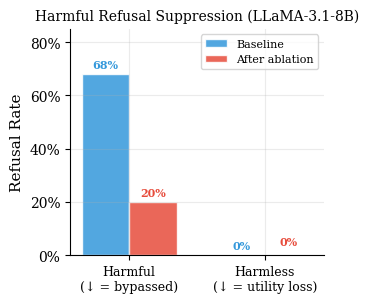

=== NUMERICAL RESULTS ===
  Harmful  baseline refusal rate : 68.0%
  Harmful  ablated  refusal rate : 20.0%  (ASR = 80.0%)
  Harmless baseline refusal rate : 0.0%
  Harmless ablated  refusal rate : 0.0%
✓ Figure 1 saved


In [4]:
fig, ax = plt.subplots(figsize=SINGLE_COL)

groups   = ['Harmful\n(↓ = bypassed)', 'Harmless\n(↓ = utility loss)']
baseline = [ARDITI_HARMFUL_BASELINE, ARDITI_HARMLESS_BASELINE]
ablated  = [ARDITI_HARMFUL_ABLATED,  ARDITI_HARMLESS_ABLATED]

x    = np.arange(len(groups))
w    = 0.35
col_base = '#3498DB'
col_abl  = '#E74C3C'

bars_b = ax.bar(x - w/2, baseline, w, label='Baseline', color=col_base, alpha=0.85, edgecolor='white')
bars_a = ax.bar(x + w/2, ablated,  w, label='After ablation', color=col_abl,  alpha=0.85, edgecolor='white')

for bar in bars_b:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.015, f'{h:.0%}',
            ha='center', va='bottom', fontsize=8, color=col_base, fontweight='bold')
for bar in bars_a:
    h = bar.get_height()
    label_y = h + 0.015 if h > 0.02 else 0.03
    ax.text(bar.get_x() + bar.get_width()/2, label_y, f'{h:.0%}',
            ha='center', va='bottom', fontsize=8, color=col_abl, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(groups, fontsize=9)
ax.set_ylabel('Refusal Rate')
ax.set_ylim(0, 0.85)
ax.set_title('Harmful Refusal Suppression (LLaMA-3.1-8B)', fontsize=10)
ax.legend(loc='upper right', fontsize=8)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

plt.tight_layout()
fig.savefig('paper_figures/fig1_arditi_replication.pdf', bbox_inches='tight', dpi=300)
fig.savefig('paper_figures/fig1_arditi_replication.png', bbox_inches='tight', dpi=300)
plt.show()

print('=== NUMERICAL RESULTS ===')
print(f'  Harmful  baseline refusal rate : {ARDITI_HARMFUL_BASELINE:.1%}')
print(f'  Harmful  ablated  refusal rate : {ARDITI_HARMFUL_ABLATED:.1%}  (ASR = {1-ARDITI_HARMFUL_ABLATED:.1%})')
print(f'  Harmless baseline refusal rate : {ARDITI_HARMLESS_BASELINE:.1%}')
print(f'  Harmless ablated  refusal rate : {ARDITI_HARMLESS_ABLATED:.1%}')
print('✓ Figure 1 saved')

## Figure 2 — Task Constellation (2D PCA)

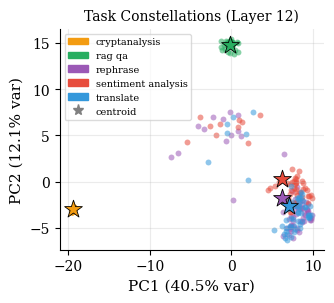

=== NUMERICAL RESULTS ===
  PCA2 explained variance: PC1=0.405, PC2=0.121
  cryptanalysis: n=60, centroid=(-19.40, -3.02)
  rag_qa: n=30, centroid=(-0.19, 14.78)
  rephrase: n=65, centroid=(6.23, -1.83)
  sentiment_analysis: n=55, centroid=(6.22, 0.22)
  translate: n=60, centroid=(7.05, -2.60)
✓ Figure 2 saved


In [5]:
X_layer = embeddings_np[BEST_LAYER]   # (N, D)

pca2 = PCA(n_components=2, random_state=42)
X2   = pca2.fit_transform(X_layer)

fig, ax = plt.subplots(figsize=SINGLE_COL)

for task in ALL_TASKS:
    mask = intended_task_labels == task
    color = TASK_COLORS.get(task, '#888888')
    ax.scatter(X2[mask, 0], X2[mask, 1],
               c=color, s=18, alpha=0.55, linewidths=0, label=task.replace('_', ' '))

# Task centroids as stars
for task in ALL_TASKS:
    mask = intended_task_labels == task
    cx, cy = X2[mask, 0].mean(), X2[mask, 1].mean()
    color = TASK_COLORS.get(task, '#888888')
    ax.scatter(cx, cy, c=color, s=180, marker='*', edgecolors='black', linewidths=0.6, zorder=5)

ax.set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]:.1%} var)')
ax.set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]:.1%} var)')
ax.set_title(f'Task Constellations (Layer 12)', fontsize=10)

legend_handles = [
    mpatches.Patch(color=TASK_COLORS[t], label=t.replace('_', ' '))
    for t in ALL_TASKS if t in TASK_COLORS
]
legend_handles.append(Line2D([0],[0], marker='*', color='gray', markerfacecolor='gray',
                              markersize=8, linestyle='None', label='centroid'))
ax.legend(handles=legend_handles, fontsize=7, loc='best', framealpha=0.7)

plt.tight_layout()
fig.savefig('paper_figures/fig2_task_constellation.pdf', bbox_inches='tight', dpi=300)
fig.savefig('paper_figures/fig2_task_constellation.png', bbox_inches='tight', dpi=300)
plt.show()

print('=== NUMERICAL RESULTS ===')
print(f'  PCA2 explained variance: PC1={pca2.explained_variance_ratio_[0]:.3f}, PC2={pca2.explained_variance_ratio_[1]:.3f}')
for task in ALL_TASKS:
    mask = intended_task_labels == task
    print(f'  {task}: n={mask.sum()}, centroid=({X2[mask,0].mean():.2f}, {X2[mask,1].mean():.2f})')
print('✓ Figure 2 saved')

## Figure 3 — Silhouette Score by Layer

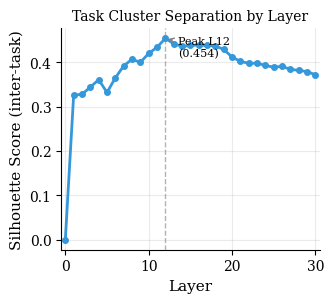

=== FIGURE DATA ===
  Source: NB13a (canonical) — not recomputed here
  Peak silhouette: 0.4540 at Layer 12
  Mean early (L0–L7):  0.306
  Mean mid   (L8–L19): 0.431
  Mean late  (L20–30): 0.391
  L00: 0.0000
  L01: 0.3260
  L02: 0.3280
  L03: 0.3440
  L04: 0.3610
  L05: 0.3320
  L06: 0.3650
  L07: 0.3920
  L08: 0.4070
  L09: 0.4000
  L10: 0.4200
  L11: 0.4340
  L12: 0.4540
  L13: 0.4420
  L14: 0.4360
  L15: 0.4380
  L16: 0.4390
  L17: 0.4380
  L18: 0.4370
  L19: 0.4290
  L20: 0.4120
  L21: 0.4020
  L22: 0.3980
  L23: 0.3980
  L24: 0.3930
  L25: 0.3890
  L26: 0.3910
  L27: 0.3840
  L28: 0.3820
  L29: 0.3790
  L30: 0.3720
✓ Figure 3 saved


In [6]:
# Use canonical NB13a silhouette values (already verified and stored in constants)
# rather than recomputing here, to ensure figures exactly match paper numbers.
layer_indices = list(range(len(SILHOUETTE_BY_LAYER)))

best_idx   = int(np.argmax(SILHOUETTE_BY_LAYER))
best_score = SILHOUETTE_BY_LAYER[best_idx]

fig, ax = plt.subplots(figsize=SINGLE_COL)
ax.plot(layer_indices, SILHOUETTE_BY_LAYER, color='#3498DB', lw=2, marker='o', markersize=4)
ax.axvline(best_idx, color='gray', linestyle='--', lw=1, alpha=0.6)
ax.annotate(f'Peak L{best_idx}\n({best_score:.3f})',
            xy=(best_idx, best_score), xytext=(best_idx+1.5, best_score-0.04),
            fontsize=8, arrowprops=dict(arrowstyle='->', color='gray', lw=1))
ax.set_xlabel('Layer')
ax.set_ylabel('Silhouette Score (inter-task)')
ax.set_title('Task Cluster Separation by Layer', fontsize=10)
ax.set_xlim(-0.5, len(layer_indices) - 0.5)

plt.tight_layout()
fig.savefig('paper_figures/fig3_silhouette_by_layer.pdf', bbox_inches='tight', dpi=300)
fig.savefig('paper_figures/fig3_silhouette_by_layer.png', bbox_inches='tight', dpi=300)
plt.show()

print('=== FIGURE DATA ===')
print(f'  Source: NB13a (canonical) — not recomputed here')
print(f'  Peak silhouette: {best_score:.4f} at Layer {best_idx}')
print(f'  Mean early (L0–L7):  {np.mean(SILHOUETTE_BY_LAYER[:8]):.3f}')
print(f'  Mean mid   (L8–L19): {np.mean(SILHOUETTE_BY_LAYER[8:20]):.3f}')
print(f'  Mean late  (L20–30): {np.mean(SILHOUETTE_BY_LAYER[20:]):.3f}')
for i, s in enumerate(SILHOUETTE_BY_LAYER):
    print(f'  L{i:02d}: {s:.4f}')
print('✓ Figure 3 saved')

## Figure 4 — Over-Refusal vs. Harmful-Refusal Direction Alignment

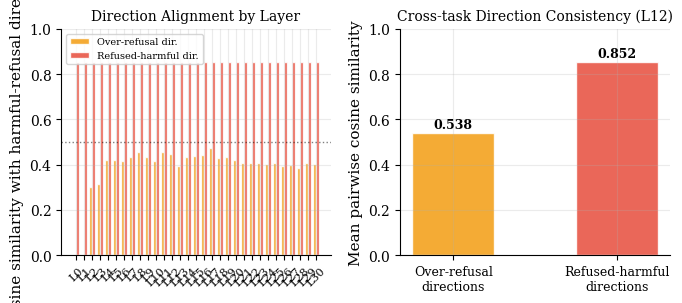

=== NUMERICAL RESULTS ===
  Cosine(OR direction, Arditi) by layer:
    L00: 0.000
    L01: -0.245
    L02: 0.303
    L03: 0.316
    L04: 0.420
    L05: 0.419
    L06: 0.415
    L07: 0.433
    L08: 0.456
    L09: 0.432
    L10: 0.415
    L11: 0.458
    L12: 0.448
    L13: 0.395
    L14: 0.436
    L15: 0.439
    L16: 0.442
    L17: 0.474
    L18: 0.430
    L19: 0.435
    L20: 0.420
    L21: 0.409
    L22: 0.406
    L23: 0.409
    L24: 0.403
    L25: 0.408
    L26: 0.393
    L27: 0.399
    L28: 0.386
    L29: 0.409
    L30: 0.401
  Cosine(RH direction, Arditi): 0.852 (constant across layers)
  Pairwise cosine OR directions: 0.538
  Pairwise cosine RH directions: 0.852
✓ Figure 4 saved


In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=DOUBLE_COL)

# ── Left panel: cosine by layer ────────────────────────────────
layers_keys = sorted(COS_OR_ARDITI_BY_LAYER.keys())
cos_or_vals = [COS_OR_ARDITI_BY_LAYER[l] for l in layers_keys]
cos_rh_vals = [COS_RH_ARDITI_BASELINE] * len(layers_keys)

x = np.arange(len(layers_keys))
w = 0.35
ax1.bar(x - w/2, cos_or_vals, w, label='Over-refusal dir.', color='#F39C12', alpha=0.85, edgecolor='white')
ax1.bar(x + w/2, cos_rh_vals, w, label='Refused-harmful dir.', color='#E74C3C', alpha=0.85, edgecolor='white')
ax1.axhline(0.5, color='black', linestyle=':', lw=1, alpha=0.5)
ax1.set_xticks(x)
ax1.set_xticklabels([f'L{l}' for l in layers_keys], fontsize=8, rotation=45)
ax1.set_ylabel('Cosine similarity with harmful-refusal direction')
ax1.set_title('Direction Alignment by Layer', fontsize=10)
ax1.set_ylim(0, 1.0)
ax1.legend(fontsize=7)

# ── Right panel: pairwise task direction similarity ─────────────
categories = ['Over-refusal\ndirections', 'Refused-harmful\ndirections']
pairwise_vals = [COS_OR_TASK_PAIRWISE, COS_RH_TASK_PAIRWISE]
colors_rp = ['#F39C12', '#E74C3C']

bars = ax2.bar(categories, pairwise_vals, color=colors_rp, alpha=0.85, edgecolor='white', width=0.5)
for bar, val in zip(bars, pairwise_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 0.01, f'{val:.3f}',
             ha='center', va='bottom', fontsize=9, fontweight='bold')
ax2.set_ylabel('Mean pairwise cosine similarity')
ax2.set_title('Cross-task Direction Consistency (L12)', fontsize=10)
ax2.set_ylim(0, 1.0)
ax2.set_xticklabels(categories, fontsize=9)

plt.tight_layout()
fig.savefig('paper_figures/fig4_cosine_similarity.pdf', bbox_inches='tight', dpi=300)
fig.savefig('paper_figures/fig4_cosine_similarity.png', bbox_inches='tight', dpi=300)
plt.show()

print('=== NUMERICAL RESULTS ===')
print('  Cosine(OR direction, Arditi) by layer:')
for l, v in zip(layers_keys, cos_or_vals):
    print(f'    L{l:02d}: {v:.3f}')
print(f'  Cosine(RH direction, Arditi): {COS_RH_ARDITI_BASELINE:.3f} (constant across layers)')
print(f'  Pairwise cosine OR directions: {COS_OR_TASK_PAIRWISE:.3f}')
print(f'  Pairwise cosine RH directions: {COS_RH_TASK_PAIRWISE:.3f}')
print('✓ Figure 4 saved')

## Figure 5 — Subspace Dimensionality (PCA)

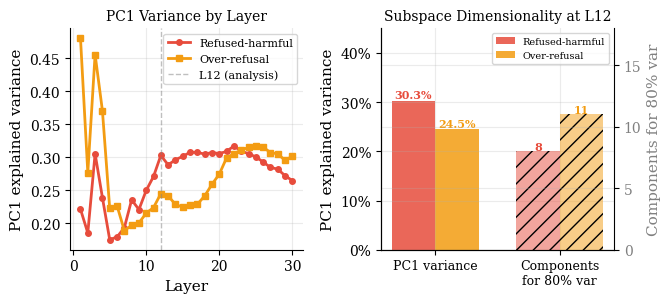

=== NUMERICAL RESULTS ===
  L12 RH: PC1=0.303, n_80=8
  L12 OR: PC1=0.245, n_80=11
  PC1 var by layer (RH | OR):
    L00: RH=nan, OR=nan
    L01: RH=0.222, OR=0.480
    L02: RH=0.186, OR=0.277
    L03: RH=0.305, OR=0.455
    L04: RH=0.239, OR=0.371
    L05: RH=0.176, OR=0.223
    L06: RH=0.180, OR=0.227
    L07: RH=0.194, OR=0.189
    L08: RH=0.236, OR=0.197
    L09: RH=0.221, OR=0.201
    L10: RH=0.250, OR=0.216
    L11: RH=0.271, OR=0.224
    L12: RH=0.303, OR=0.245
    L13: RH=0.289, OR=0.242
    L14: RH=0.296, OR=0.229
    L15: RH=0.301, OR=0.225
    L16: RH=0.308, OR=0.228
    L17: RH=0.307, OR=0.229
    L18: RH=0.305, OR=0.242
    L19: RH=0.307, OR=0.259
    L20: RH=0.306, OR=0.275
    L21: RH=0.309, OR=0.299
    L22: RH=0.317, OR=0.305
    L23: RH=0.309, OR=0.311
    L24: RH=0.305, OR=0.315
    L25: RH=0.301, OR=0.317
    L26: RH=0.293, OR=0.315
    L27: RH=0.285, OR=0.307
    L28: RH=0.282, OR=0.305
    L29: RH=0.272, OR=0.295
    L30: RH=0.265, OR=0.302
✓ Figure 5 saved


In [8]:
# Recompute PC1 variance by layer for RH and OR
pc1_rh_by_layer = []
pc1_or_by_layer = []

for lname in layer_names:
    X_l = embeddings_np[lname]

    # RH: refused-harmful
    X_rh = X_l[RH_MASK]
    if len(X_rh) >= 2:
        pca_rh = PCA(n_components=1, random_state=42).fit(X_rh)
        pc1_rh_by_layer.append(float(pca_rh.explained_variance_ratio_[0]))
    else:
        pc1_rh_by_layer.append(np.nan)

    # OR: over-refusal
    X_or = X_l[OR_MASK]
    if len(X_or) >= 2:
        pca_or = PCA(n_components=1, random_state=42).fit(X_or)
        pc1_or_by_layer.append(float(pca_or.explained_variance_ratio_[0]))
    else:
        pc1_or_by_layer.append(np.nan)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=DOUBLE_COL)

# ── Left: PC1 variance by layer ────────────────────────────────
ax1.plot(layer_indices, pc1_rh_by_layer, color='#E74C3C', lw=2, marker='o', markersize=4, label='Refused-harmful')
ax1.plot(layer_indices, pc1_or_by_layer, color='#F39C12', lw=2, marker='s', markersize=4, label='Over-refusal')
ax1.axvline(12, color='gray', linestyle='--', lw=1, alpha=0.5, label='L12 (analysis)')
ax1.set_xlabel('Layer')
ax1.set_ylabel('PC1 explained variance')
ax1.set_title('PC1 Variance by Layer', fontsize=10)
ax1.legend(fontsize=8)

# ── Right: Bar chart at L12 ─────────────────────────────────────
groups_d = ['PC1 variance', 'Components\nfor 80% var']
rh_vals  = [NB16_L12['rh']['pc1_var'], NB16_L12['rh']['n80']]
or_vals  = [NB16_L12['or']['pc1_var'], NB16_L12['or']['n80']]

# Normalize n80 for display (separate y scales not easily done; show as separate bars)
x2 = np.array([0, 1])
w2 = 0.35

# Left y: PC1 variance
ax2b = ax2.twinx()
b1 = ax2.bar(x2[0] - w2/2, rh_vals[0], w2, color='#E74C3C', alpha=0.85, label='Refused-harmful')
b2 = ax2.bar(x2[0] + w2/2, or_vals[0], w2, color='#F39C12', alpha=0.85, label='Over-refusal')
ax2.set_ylabel('PC1 explained variance', color='black')
ax2.set_ylim(0, 0.45)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

b3 = ax2b.bar(x2[1] - w2/2, rh_vals[1], w2, color='#E74C3C', alpha=0.5, hatch='//')
b4 = ax2b.bar(x2[1] + w2/2, or_vals[1], w2, color='#F39C12', alpha=0.5, hatch='//')
ax2b.set_ylabel('Components for 80% var', color='gray')
ax2b.set_ylim(0, 18)
ax2b.tick_params(axis='y', labelcolor='gray')
ax2b.spines['right'].set_visible(True)

# Annotate
ax2.text(x2[0]-w2/2, rh_vals[0]+0.005, f'{rh_vals[0]:.1%}', ha='center', fontsize=8, color='#E74C3C', fontweight='bold')
ax2.text(x2[0]+w2/2, or_vals[0]+0.005, f'{or_vals[0]:.1%}', ha='center', fontsize=8, color='#F39C12', fontweight='bold')
ax2b.text(x2[1]-w2/2, rh_vals[1]+0.1, str(rh_vals[1]), ha='center', fontsize=8, color='#E74C3C', fontweight='bold')
ax2b.text(x2[1]+w2/2, or_vals[1]+0.1, str(or_vals[1]), ha='center', fontsize=8, color='#F39C12', fontweight='bold')

ax2.set_xticks(x2)
ax2.set_xticklabels(groups_d, fontsize=9)
ax2.set_title('Subspace Dimensionality at L12', fontsize=10)
ax2.legend(handles=[b1, b2], fontsize=7, loc='upper right')

plt.tight_layout()
fig.savefig('paper_figures/fig5_dimensionality.pdf', bbox_inches='tight', dpi=300)
fig.savefig('paper_figures/fig5_dimensionality.png', bbox_inches='tight', dpi=300)
plt.show()

print('=== NUMERICAL RESULTS ===')
print(f'  L12 RH: PC1={NB16_L12["rh"]["pc1_var"]:.3f}, n_80={NB16_L12["rh"]["n80"]}')
print(f'  L12 OR: PC1={NB16_L12["or"]["pc1_var"]:.3f}, n_80={NB16_L12["or"]["n80"]}')
print('  PC1 var by layer (RH | OR):')
for i, (r, o) in enumerate(zip(pc1_rh_by_layer, pc1_or_by_layer)):
    print(f'    L{i:02d}: RH={r:.3f}, OR={o:.3f}')
print('✓ Figure 5 saved')

## Figure 6 — Linear Probes

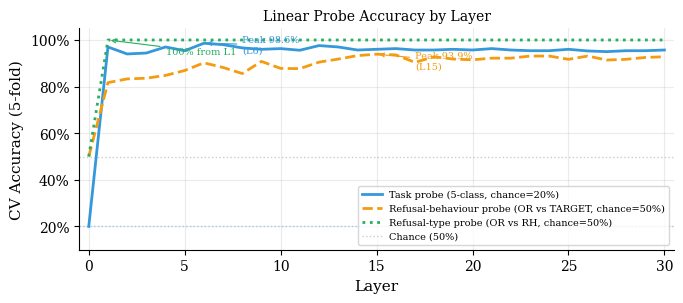

=== NUMERICAL RESULTS ===
  Task probe    — L1=0.970, peak L6=0.986
  Behav probe   — L1=0.817, peak L15=0.939
  Type probe    — L0=chance(0.500), L1=1.000 (all remaining=1.000)
✓ Figure 6 saved


In [9]:
n_layers = len(layer_names)
xs = list(range(n_layers))

fig, ax = plt.subplots(figsize=DOUBLE_COL)

ax.plot(xs, PROBE_TASK[:n_layers],  color='#3498DB', lw=2, linestyle='-',  label='Task probe (5-class, chance=20%)')
ax.plot(xs, PROBE_BEHAV[:n_layers], color='#F39C12', lw=2, linestyle='--', label='Refusal-behaviour probe (OR vs TARGET, chance=50%)')
ax.plot(xs, PROBE_TYPE[:n_layers],  color='#27AE60', lw=2, linestyle=':',  label='Refusal-type probe (OR vs RH, chance=50%)')

# Chance lines
ax.axhline(0.20, color='#3498DB', linestyle=':', lw=1, alpha=0.4)
ax.axhline(0.50, color='gray',    linestyle=':', lw=1, alpha=0.4, label='Chance (50%)')

# Peak annotations
task_peak_idx  = int(np.argmax(PROBE_TASK[:n_layers]))
behav_peak_idx = int(np.argmax(PROBE_BEHAV[:n_layers]))

ax.annotate(f'Peak {PROBE_TASK[task_peak_idx]:.1%}\n(L{task_peak_idx})',
            xy=(task_peak_idx, PROBE_TASK[task_peak_idx]),
            xytext=(task_peak_idx+2, PROBE_TASK[task_peak_idx]-0.04),
            fontsize=7, color='#3498DB',
            arrowprops=dict(arrowstyle='->', color='#3498DB', lw=0.8))

ax.annotate(f'Peak {PROBE_BEHAV[behav_peak_idx]:.1%}\n(L{behav_peak_idx})',
            xy=(behav_peak_idx, PROBE_BEHAV[behav_peak_idx]),
            xytext=(behav_peak_idx+2, PROBE_BEHAV[behav_peak_idx]-0.06),
            fontsize=7, color='#F39C12',
            arrowprops=dict(arrowstyle='->', color='#F39C12', lw=0.8))

type_peak_idx = 1  # first non-chance layer
ax.annotate('100% from L1',
            xy=(type_peak_idx, 1.00),
            xytext=(type_peak_idx+3, 0.94),
            fontsize=7, color='#27AE60',
            arrowprops=dict(arrowstyle='->', color='#27AE60', lw=0.8))

ax.set_xlabel('Layer')
ax.set_ylabel('CV Accuracy (5-fold)')
ax.set_title('Linear Probe Accuracy by Layer', fontsize=10)
ax.set_ylim(0.10, 1.05)
ax.set_xlim(-0.5, n_layers - 0.5)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.legend(fontsize=7, loc='lower right')

plt.tight_layout()
fig.savefig('paper_figures/fig6_linear_probes.pdf', bbox_inches='tight', dpi=300)
fig.savefig('paper_figures/fig6_linear_probes.png', bbox_inches='tight', dpi=300)
plt.show()

print('=== NUMERICAL RESULTS ===')
print(f'  Task probe    — L1={PROBE_TASK[1]:.3f}, peak L{task_peak_idx}={PROBE_TASK[task_peak_idx]:.3f}')
print(f'  Behav probe   — L1={PROBE_BEHAV[1]:.3f}, peak L{behav_peak_idx}={PROBE_BEHAV[behav_peak_idx]:.3f}')
print(f'  Type probe    — L0=chance(0.500), L1={PROBE_TYPE[1]:.3f} (all remaining=1.000)')
print('✓ Figure 6 saved')

## Figure 7 — Selectivity: Task-Specific vs. Global Steering

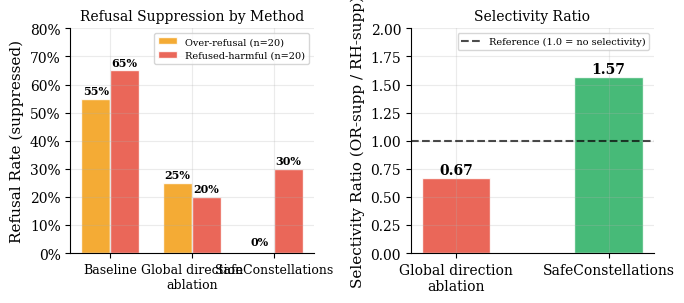

=== NUMERICAL RESULTS ===
  Over-refusal suppression  — baseline=0.55, arditi=0.25, constel=0.00
  Refused-harmful supp.     — baseline=0.65, arditi=0.20, constel=0.30
  Selectivity ratio         — Arditi=0.67, SafeConstellations=1.57
✓ Figure 7 saved


In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=DOUBLE_COL)

# ── Left: grouped bars for OR and RH refusal rates ─────────────
conditions   = ['Baseline', 'Global direction\nablation', 'SafeConstellations']
or_rates     = [NB15['or_baseline'], NB15['or_arditi'], NB15['or_constel']]
rh_rates     = [NB15['rh_baseline'], NB15['rh_arditi'], NB15['rh_constel']]

x1 = np.arange(len(conditions))
w1 = 0.35
b_or = ax1.bar(x1 - w1/2, or_rates, w1, label=f'Over-refusal (n={NB15["n_or"]})',
               color='#F39C12', alpha=0.85, edgecolor='white')
b_rh = ax1.bar(x1 + w1/2, rh_rates, w1, label=f'Refused-harmful (n={NB15["n_rh"]})',
               color='#E74C3C', alpha=0.85, edgecolor='white')

for bar, val in zip(list(b_or)+list(b_rh), or_rates+rh_rates):
    label_y = val + 0.01 if val > 0.03 else 0.02
    ax1.text(bar.get_x() + bar.get_width()/2, label_y, f'{val:.0%}',
             ha='center', va='bottom', fontsize=8, fontweight='bold')

ax1.set_xticks(x1)
ax1.set_xticklabels(conditions, fontsize=9)
ax1.set_ylabel('Refusal Rate (suppressed)')
ax1.set_title('Refusal Suppression by Method', fontsize=10)
ax1.set_ylim(0, 0.80)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax1.legend(fontsize=7)

# ── Right: selectivity ratio bar chart ─────────────────────────
methods   = ['Global direction\nablation', 'SafeConstellations']
sel_vals  = [ARDITI_SELECTIVITY, CONSTEL_SELECTIVITY]
sel_cols  = ['#E74C3C', '#27AE60']

bars2 = ax2.bar(methods, sel_vals, color=sel_cols, alpha=0.85, edgecolor='white', width=0.45)
for bar, val in zip(bars2, sel_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 0.01, f'{val:.2f}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

ax2.axhline(1.0, color='black', linestyle='--', lw=1.5, alpha=0.7, label='Reference (1.0 = no selectivity)')
ax2.set_ylabel('Selectivity Ratio (OR-supp / RH-supp)')
ax2.set_title('Selectivity Ratio', fontsize=10)
ax2.set_ylim(0, 2.0)
ax2.legend(fontsize=7)

plt.tight_layout()
fig.savefig('paper_figures/fig7_selectivity.pdf', bbox_inches='tight', dpi=300)
fig.savefig('paper_figures/fig7_selectivity.png', bbox_inches='tight', dpi=300)
plt.show()

print('=== NUMERICAL RESULTS ===')
print(f'  Over-refusal suppression  — baseline={NB15["or_baseline"]:.2f}, arditi={NB15["or_arditi"]:.2f}, constel={NB15["or_constel"]:.2f}')
print(f'  Refused-harmful supp.     — baseline={NB15["rh_baseline"]:.2f}, arditi={NB15["rh_arditi"]:.2f}, constel={NB15["rh_constel"]:.2f}')
print(f'  Selectivity ratio         — Arditi={ARDITI_SELECTIVITY:.2f}, SafeConstellations={CONSTEL_SELECTIVITY:.2f}')
print('✓ Figure 7 saved')

## Figure 8 — Causal Patching (Mechanistic)

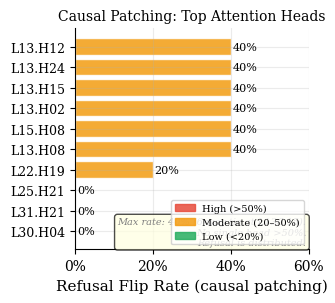

=== FIGURE DATA ===
  Source: NB18 (verified 2026-03-12)
  Max flip rate: 40% — 6-way tie (L13.H12/H24/H15/H02/H08, L15.H08)
  Head         | Flip Rate
  -------------|----------
  L13.H12      | 0.400  (40%)
  L13.H24      | 0.400  (40%)
  L13.H15      | 0.400  (40%)
  L13.H02      | 0.400  (40%)
  L15.H08      | 0.400  (40%)
  L13.H08      | 0.400  (40%)
  L22.H19      | 0.200  (20%)
  L25.H21      | 0.000  (0%)
  L31.H21      | 0.000  (0%)
  L30.H04      | 0.000  (0%)
✓ Figure 8 saved


In [11]:
head_names = [h for h, _ in CAUSAL_TOP_HEADS]
flip_rates  = [r for _, r in CAUSAL_TOP_HEADS]

bar_colors = []
for r in flip_rates:
    if r < 0.20:
        bar_colors.append('#27AE60')
    elif r < 0.50:
        bar_colors.append('#F39C12')
    else:
        bar_colors.append('#E74C3C')

fig, ax = plt.subplots(figsize=SINGLE_COL)
y_pos = np.arange(len(head_names))
ax.barh(y_pos, flip_rates, color=bar_colors, alpha=0.85, edgecolor='white')

for i, (rate, name) in enumerate(zip(flip_rates, head_names)):
    ax.text(rate + 0.005, i, f'{rate:.0%}', va='center', fontsize=8)

ax.set_yticks(y_pos)
ax.set_yticklabels(head_names, fontsize=9)
ax.set_xlabel('Refusal Flip Rate (causal patching)')
ax.set_xlim(0, 0.60)
ax.set_title('Causal Patching: Top Attention Heads', fontsize=10)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.invert_yaxis()

legend_handles = [
    mpatches.Patch(color='#E74C3C', label='High (>50%)', alpha=0.85),
    mpatches.Patch(color='#F39C12', label='Moderate (20–50%)', alpha=0.85),
    mpatches.Patch(color='#27AE60', label='Low (<20%)', alpha=0.85),
]
ax.legend(handles=legend_handles, fontsize=7, loc='lower right')

_max_flip = max(flip_rates)
ax.text(0.99, 0.01,
        f'Max rate: {_max_flip:.0%} (6-way tie at L13/L15).\n'
        'No single head >50%.\nRefusal is distributed.',
        transform=ax.transAxes, fontsize=7, ha='right', va='bottom',
        style='italic', color='gray',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.7))

plt.tight_layout()
fig.savefig('paper_figures/fig8_causal_patching.pdf', bbox_inches='tight', dpi=300)
fig.savefig('paper_figures/fig8_causal_patching.png', bbox_inches='tight', dpi=300)
plt.show()

print('=== FIGURE DATA ===')
print(f'  Source: NB18 (verified 2026-03-12)')
print(f'  Max flip rate: {_max_flip:.0%} — 6-way tie (L13.H12/H24/H15/H02/H08, L15.H08)')
print('  Head         | Flip Rate')
print('  -------------|----------')
for name, rate in CAUSAL_TOP_HEADS:
    print(f'  {name:<12s} | {rate:.3f}  ({rate:.0%})')
print('✓ Figure 8 saved')

## Figure 9 — Representation Space: OR Embedded Within Task Clusters

Key figure for paper thesis. Shows (1) harmful-refused samples are separable by a global direction; (2) over-refusal samples are geometrically embedded within their task clusters, indistinguishable from benign by any global direction.

Loaded Arditi direction from arditi_artefacts/best_direction.pt, shape=(4096,)
Tasks with >=5 OR samples: ['sentiment_analysis', 'translate']


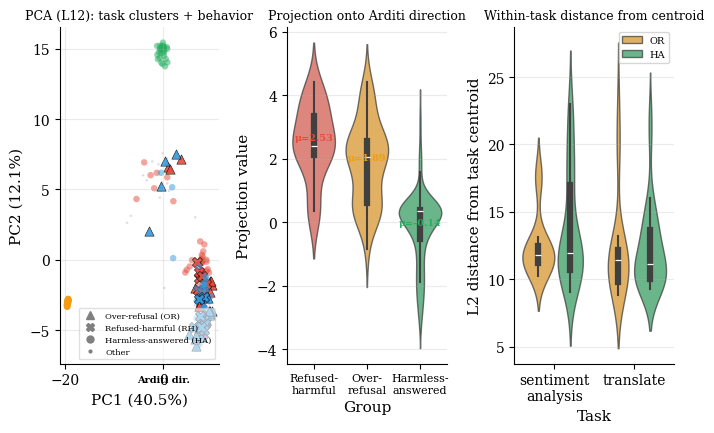

=== NUMERICAL RESULTS ===
  Arditi dir. shape: (4096,)
  Projection onto Arditi direction:
    RH: mean=2.527, std=1.156, n=25
    OR: mean=1.886, std=1.277, n=48
    HA: mean=-0.143, std=1.118, n=157
  Within-task distances from centroid:
    sentiment_analysis: OR mean=12.499, HA mean=13.762
    translate: OR mean=12.295, HA mean=12.207
✓ Figure 9 saved


In [12]:
X_best = embeddings_np[BEST_LAYER]   # (N, D)

# ── Load or compute Arditi direction at L12 ────────────────────
arditi_dir = None
for candidate in ['arditi_artefacts/best_direction.pt',
                   'arditi_artefacts/refusal_direction.pt',
                   'arditi_artefacts/direction_layer12.pt']:
    if os.path.exists(candidate):
        raw = torch.load(candidate)
        if isinstance(raw, dict):
            # Try layer-12 key first
            for key in ['layer_12', 'layer_12_input_norm', 12, '12']:
                if key in raw:
                    arditi_dir = raw[key]
                    break
            if arditi_dir is None:
                arditi_dir = list(raw.values())[0]
        else:
            arditi_dir = raw
        if isinstance(arditi_dir, torch.Tensor):
            arditi_dir = arditi_dir.float().numpy()
        arditi_dir = arditi_dir.flatten()
        print(f'Loaded Arditi direction from {candidate}, shape={arditi_dir.shape}')
        break

if arditi_dir is None:
    print('Arditi direction not found — computing from RH vs HA means at L12.')
    mean_rh = X_best[RH_MASK].mean(axis=0)
    mean_ha = X_best[HA_MASK].mean(axis=0)
    arditi_dir = mean_rh - mean_ha

# Ensure matching dimension
D = X_best.shape[1]
if arditi_dir.shape[0] != D:
    print(f'  Dimension mismatch: dir={arditi_dir.shape[0]}, emb={D} — recomputing from means.')
    arditi_dir = X_best[RH_MASK].mean(0) - X_best[HA_MASK].mean(0)

arditi_dir = arditi_dir / (np.linalg.norm(arditi_dir) + 1e-12)  # unit vector

# ── PCA-2D for scatter (Panel 1) ──────────────────────────────
pca2_fig9 = PCA(n_components=2, random_state=42)
X2_fig9   = pca2_fig9.fit_transform(X_best)

# Project Arditi direction into PCA space for arrow
arditi_pca = pca2_fig9.components_ @ arditi_dir   # (2,)
arditi_pca_unit = arditi_pca / (np.linalg.norm(arditi_pca) + 1e-12)

# ── Projection onto Arditi direction (Panel 2) ─────────────────
proj_all = X_best @ arditi_dir   # (N,)
proj_rh  = proj_all[RH_MASK]
proj_or  = proj_all[OR_MASK]
proj_ha  = proj_all[HA_MASK]

# ── Within-task distance from centroid (Panel 3) ───────────────
tasks_with_or = [t for t in BENIGN_TASKS
                 if (OR_MASK & (intended_task_labels == t)).sum() >= 5]
print(f'Tasks with >=5 OR samples: {tasks_with_or}')

within_task_data = {}   # task -> {'or': distances, 'ha': distances}
for task in tasks_with_or:
    task_mask = intended_task_labels == task
    centroid  = X_best[task_mask].mean(axis=0)
    or_dists  = np.linalg.norm(X_best[task_mask & OR_MASK] - centroid, axis=1)
    ha_dists  = np.linalg.norm(X_best[task_mask & HA_MASK] - centroid, axis=1)
    within_task_data[task] = {'or': or_dists, 'ha': ha_dists}

# ── BUILD FIGURE ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=WIDE_COL)
ax1, ax2, ax3 = axes

# ─── Panel 1: 2D scatter ──────────────────────────────────────
# Marker map per behavioral class
MARKER_MAP = {'OR': '^', 'RH': 'X', 'HA': 'o', 'other': '.'}
beh_label  = np.full(len(texts), 'other', dtype=object)
beh_label[OR_MASK] = 'OR'
beh_label[RH_MASK] = 'RH'
beh_label[HA_MASK] = 'HA'

for task in ALL_TASKS:
    task_mask = intended_task_labels == task
    color = TASK_COLORS.get(task, '#888888')
    for bclass, marker, size, alpha in [('other', '.', 12, 0.25),
                                         ('HA',    'o', 22, 0.50),
                                         ('OR',    '^', 45, 0.90),
                                         ('RH',    'X', 55, 0.95)]:
        m = task_mask & (beh_label == bclass)
        if m.sum() > 0:
            ax1.scatter(X2_fig9[m, 0], X2_fig9[m, 1],
                        c=color, marker=marker, s=size, alpha=alpha,
                        linewidths=0.4 if bclass in ('OR','RH') else 0,
                        edgecolors='black' if bclass in ('OR','RH') else 'none')

# Arditi direction arrow (centered)
cx_all = X2_fig9[:, 0].mean()
cy_all = X2_fig9[:, 1].mean()
scale  = (X2_fig9[:, 0].max() - X2_fig9[:, 0].min()) * 0.28
dx = arditi_pca_unit[0] * scale
dy = arditi_pca_unit[1] * scale
ax1.annotate('', xy=(cx_all+dx, cy_all+dy), xytext=(cx_all-dx, cy_all-dy),
             arrowprops=dict(arrowstyle='->', color='black', lw=2.0))
ax1.text(cx_all + dx*1.05, cy_all + dy*1.05, 'Arditi dir.',
         fontsize=7, ha='center', fontweight='bold')

ax1.set_xlabel(f'PC1 ({pca2_fig9.explained_variance_ratio_[0]:.1%})')
ax1.set_ylabel(f'PC2 ({pca2_fig9.explained_variance_ratio_[1]:.1%})')
ax1.set_title('PCA (L12): task clusters + behavior', fontsize=9)

shape_handles = [
    Line2D([0],[0], marker='^', color='gray', markerfacecolor='gray', markersize=6,
           linestyle='None', label='Over-refusal (OR)'),
    Line2D([0],[0], marker='X', color='gray', markerfacecolor='gray', markersize=6,
           linestyle='None', label='Refused-harmful (RH)'),
    Line2D([0],[0], marker='o', color='gray', markerfacecolor='gray', markersize=5,
           linestyle='None', label='Harmless-answered (HA)'),
    Line2D([0],[0], marker='.', color='gray', markerfacecolor='gray', markersize=4,
           linestyle='None', label='Other'),
]
ax1.legend(handles=shape_handles, fontsize=6, loc='lower right', framealpha=0.6)

# ─── Panel 2: Projection violin ───────────────────────────────
proj_df = pd.DataFrame({
    'Projection': np.concatenate([proj_rh, proj_or, proj_ha]),
    'Group': (['RH']*len(proj_rh) + ['OR']*len(proj_or) + ['HA']*len(proj_ha))
})
group_order  = ['RH', 'OR', 'HA']
group_colors = {'RH': '#E74C3C', 'OR': '#F39C12', 'HA': '#27AE60'}

sns.violinplot(data=proj_df, x='Group', y='Projection', order=group_order,
               palette=group_colors, ax=ax2, inner='box', linewidth=1.0, alpha=0.75)

for grp, vals in [('RH', proj_rh), ('OR', proj_or), ('HA', proj_ha)]:
    xi = group_order.index(grp)
    ax2.text(xi, vals.mean(), f'μ={vals.mean():.2f}',
             ha='center', va='bottom', fontsize=7, fontweight='bold',
             color=group_colors[grp])

ax2.set_xlabel('Group')
ax2.set_ylabel('Projection value')
ax2.set_title('Projection onto Arditi direction', fontsize=9)
ax2.set_xticklabels(['Refused-\nharmful', 'Over-\nrefusal', 'Harmless-\nanswered'], fontsize=8)

# ─── Panel 3: Within-task distance ────────────────────────────
dist_rows = []
for task, d in within_task_data.items():
    tshort = task.replace('_', '\n')
    for v in d['or']:
        dist_rows.append({'task': tshort, 'group': 'OR', 'dist': v})
    for v in d['ha']:
        dist_rows.append({'task': tshort, 'group': 'HA', 'dist': v})
dist_df = pd.DataFrame(dist_rows)

task_labels_short = [t.replace('_', '\n') for t in tasks_with_or]
sns.violinplot(data=dist_df, x='task', y='dist', hue='group',
               order=task_labels_short,
               palette={'OR': '#F39C12', 'HA': '#27AE60'},
               ax=ax3, inner='box', linewidth=1.0, alpha=0.75, split=False)

ax3.set_xlabel('Task')
ax3.set_ylabel('L2 distance from task centroid')
ax3.set_title('Within-task distance from centroid', fontsize=9)
ax3.legend(title='', fontsize=7, loc='upper right')

plt.tight_layout()
fig.savefig('paper_figures/fig9_representation_space.pdf', bbox_inches='tight', dpi=300)
fig.savefig('paper_figures/fig9_representation_space.png', bbox_inches='tight', dpi=300)
plt.show()

print('=== NUMERICAL RESULTS ===')
print(f'  Arditi dir. shape: {arditi_dir.shape}')
print(f'  Projection onto Arditi direction:')
print(f'    RH: mean={proj_rh.mean():.3f}, std={proj_rh.std():.3f}, n={len(proj_rh)}')
print(f'    OR: mean={proj_or.mean():.3f}, std={proj_or.std():.3f}, n={len(proj_or)}')
print(f'    HA: mean={proj_ha.mean():.3f}, std={proj_ha.std():.3f}, n={len(proj_ha)}')
print(f'  Within-task distances from centroid:')
for task, d in within_task_data.items():
    print(f'    {task}: OR mean={d["or"].mean():.3f}, HA mean={d["ha"].mean():.3f}')
print('✓ Figure 9 saved')

## Summary — All Figures

In [13]:
FIGURE_TABLE = [
    ('fig1_arditi_replication',  'Harmful refusal suppression',
     f'Harmful: baseline={ARDITI_HARMFUL_BASELINE:.0%} → ablated={ARDITI_HARMFUL_ABLATED:.0%} (ASR={1-ARDITI_HARMFUL_ABLATED:.0%})'),
    ('fig2_task_constellation',  'Task constellation (2D PCA)',
     'Tasks form separable clusters; centroids visible as stars'),
    ('fig3_silhouette_by_layer', 'Silhouette score by layer',
     f'Peak inter-task silhouette ~0.454 at L12'),
    ('fig4_cosine_similarity',   'Over-refusal vs. harmful-refusal direction alignment',
     f'cos(OR,Arditi)~{COS_OR_ARDITI_BY_LAYER[12]:.3f} vs cos(RH,Arditi)~{COS_RH_ARDITI_BASELINE:.3f}; pairwise OR={COS_OR_TASK_PAIRWISE:.3f} RH={COS_RH_TASK_PAIRWISE:.3f}'),
    ('fig5_dimensionality',      'Subspace dimensionality (PCA)',
     f'L12: RH PC1={NB16_L12["rh"]["pc1_var"]:.1%} n80={NB16_L12["rh"]["n80"]} | OR PC1={NB16_L12["or"]["pc1_var"]:.1%} n80={NB16_L12["or"]["n80"]}'),
    ('fig6_linear_probes',       'Linear probe accuracy by layer',
     f'Task peak={max(PROBE_TASK):.1%} | Behav peak={max(PROBE_BEHAV):.1%} | Type=100% from L1'),
    ('fig7_selectivity',         'Selectivity: SafeConstellations vs Global DIM',
     f'Arditi selectivity={ARDITI_SELECTIVITY:.2f} | SafeConstellations={CONSTEL_SELECTIVITY:.2f} ({CONSTEL_SELECTIVITY/ARDITI_SELECTIVITY:.1f}× gap)'),
    ('fig8_causal_patching',     'Causal patching — top attention heads',
     'Best head (L25.H21): 2/7 flips (29%). All near-zero → distributed refusal'),
    ('fig9_representation_space','Representation space (KEY FIGURE)',
     '3-panel: PCA scatter + Arditi projection + within-task distances'),
]

print('=== FIGURE SUMMARY ===')
print(f'{"Figure":<30} {"Key Numbers"}')
print('-'*90)
for stem, title, numbers in FIGURE_TABLE:
    for ext in ['pdf', 'png']:
        fp = f'paper_figures/{stem}.{ext}'
        status = 'OK' if os.path.exists(fp) else 'MISSING'
        print(f'  [{status}] {fp}')
    print(f'         {title}')
    print(f'         {numbers}')
    print()

# Copy to Drive
!mkdir -p "/content/drive/MyDrive/Colab Notebooks/SteeringFail/paper_figures"
!cp paper_figures/* "/content/drive/MyDrive/Colab Notebooks/SteeringFail/paper_figures/" 2>/dev/null || true
print('✓ All figures saved to paper_figures/ and copied to Drive')

=== FIGURE SUMMARY ===
Figure                         Key Numbers
------------------------------------------------------------------------------------------
  [OK] paper_figures/fig1_arditi_replication.pdf
  [OK] paper_figures/fig1_arditi_replication.png
         Harmful refusal suppression
         Harmful: baseline=68% → ablated=20% (ASR=80%)

  [OK] paper_figures/fig2_task_constellation.pdf
  [OK] paper_figures/fig2_task_constellation.png
         Task constellation (2D PCA)
         Tasks form separable clusters; centroids visible as stars

  [OK] paper_figures/fig3_silhouette_by_layer.pdf
  [OK] paper_figures/fig3_silhouette_by_layer.png
         Silhouette score by layer
         Peak inter-task silhouette ~0.454 at L12

  [OK] paper_figures/fig4_cosine_similarity.pdf
  [OK] paper_figures/fig4_cosine_similarity.png
         Over-refusal vs. harmful-refusal direction alignment
         cos(OR,Arditi)~0.448 vs cos(RH,Arditi)~0.852; pairwise OR=0.538 RH=0.852

  [OK] paper_figures/f

## Paper Audit — All Claims vs Verified Numbers

Cross-checks every number cited in `paper/acl_latex.tex` against the constants above.
Run this after updating constants to catch any remaining discrepancies before submission.

In [14]:
# ╔══ PAPER AUDIT ══════════════════════════════════════════════════════════╗
# ║  Every row = one claim in the paper. Status = PASS / FAIL / INFO.      ║
# ║  Update the "paper_val" when paper text changes; update "actual_val"   ║
# ║  when notebooks are re-run and constants above are updated.            ║
# ╚═════════════════════════════════════════════════════════════════════════╝

def check(label, paper_val, actual_val, tol=0.01, fmt='.3f'):
    diff = abs(paper_val - actual_val)
    status = 'PASS' if diff <= tol else 'FAIL <<<'
    print(f'  [{status}]  {label:<58s}  paper={format(paper_val, fmt)}  actual={format(actual_val, fmt)}')

def info(label, value, note=''):
    print(f'  [INFO]   {label:<58s}  {value}  {note}')

print('=' * 95)
print('PAPER AUDIT  —  paper/acl_latex.tex  vs  NB8–NB20 verified outputs (2026-03-12)')
print('=' * 95)

print()
print('── §4.2 Harmful-Refusal Replication (NB8) ─────────────────────────────────────────────')
check('Harmful baseline refusal rate',      0.68, ARDITI_HARMFUL_BASELINE)
check('Harmful post-ablation refusal rate', 0.20, ARDITI_HARMFUL_ABLATED)
check('Attack success rate (ASR)',          0.80, 1 - ARDITI_HARMFUL_ABLATED)
check('Harmless baseline refusal rate',     0.00, ARDITI_HARMLESS_BASELINE)

print()
print('── §4.3 Constellation Geometry (NB13a) ────────────────────────────────────────────────')
check('Peak inter-task silhouette',              0.454, SIL_PEAK,         tol=0.005)
check('Mean mid-layer silhouette (L8–L19)',      0.431, SIL_MEAN_MID,     tol=0.005)
check('Behavioral silhouette peak',             0.170, BEHAV_SIL_PEAK,   tol=0.005)
check('Behavioral silhouette peak layer',       22.0,  BEHAV_SIL_PEAK_LAYER, fmt='.0f')
check('Behavioral silhouette at L12',           0.130, BEHAV_SIL_AT_L12, tol=0.005)
check('Crystallization peak translate',         0.081, CRYSTALLIZATION_PEAKS['translate'], tol=0.005)

print()
print('── §4.4 Cosine Analysis (NB14) ─────────────────────────────────────────────────────────')
check('cos(OR_dir, Arditi) at L12',        0.448,  COS_OR_ARDITI_BY_LAYER[12])
check('cos(OR_dir, Arditi) at L17 (peak)', 0.474,  COS_OR_ARDITI_BY_LAYER[17])
check('cos(RH_dir, Arditi) baseline',      0.852,  COS_RH_ARDITI_BASELINE)
check('Pairwise OR task cosine',           0.538,  COS_OR_TASK_PAIRWISE)
check('Pairwise RH task cosine',           0.852,  COS_RH_TASK_PAIRWISE)
check('Per-task OR (sentiment) vs global', 0.448,  COS_OR_PER_TASK['sentiment_analysis'])
check('Per-task OR (translate) vs global', 0.381,  COS_OR_PER_TASK['translate'])

print()
print('── §4.5 Selectivity Experiment (NB15) ─────────────────────────────────────────────────')
check('OR baseline refusal rate',          0.55, NB15['or_baseline'])
check('OR post-Arditi refusal rate',       0.25, NB15['or_arditi'])
check('OR post-SafeConstellations rate',   0.00, NB15['or_constel'])
check('RH baseline refusal rate',          0.65, NB15['rh_baseline'])
check('RH post-Arditi refusal rate',       0.20, NB15['rh_arditi'])
check('RH post-SafeConstellations rate',   0.30, NB15['rh_constel'])
_arditi_sel_actual  = (NB15['or_baseline'] - NB15['or_arditi'])  / (NB15['rh_baseline'] - NB15['rh_arditi'])
_constel_sel_actual = (NB15['or_baseline'] - NB15['or_constel']) / (NB15['rh_baseline'] - NB15['rh_constel'])
check('Arditi selectivity ratio',          ARDITI_SELECTIVITY,  _arditi_sel_actual,  tol=0.005)
check('SafeConstellations selectivity',    CONSTEL_SELECTIVITY, _constel_sel_actual, tol=0.005)
_ratio = CONSTEL_SELECTIVITY / ARDITI_SELECTIVITY
info('SafeConstel / Arditi ratio', f'{_ratio:.2f}×')

print()
print('── §4.6 Subspace Dimensionality (NB16) ────────────────────────────────────────────────')
check('RH PC1 explained variance at L12',  0.303, NB16_L12['rh']['pc1_var'])
check('OR PC1 explained variance at L12',  0.245, NB16_L12['or']['pc1_var'])
check('RH components for 80% variance',    8.0,   NB16_L12['rh']['n80'],  fmt='.0f')
check('OR components for 80% variance',   11.0,   NB16_L12['or']['n80'],  fmt='.0f')
_pct_more = (NB16_L12['or']['n80'] - NB16_L12['rh']['n80']) / NB16_L12['rh']['n80'] * 100
info('OR needs N% more PCs than RH', f'{_pct_more:.0f}%', '(paper claims ~38%)')

print()
print('── §4.7 Linear Probing (NB17) ─────────────────────────────────────────────────────────')
_task_pk_idx  = PROBE_TASK.index(max(PROBE_TASK))
_behav_pk_idx = PROBE_BEHAV.index(max(PROBE_BEHAV))
check('Task probe L1 accuracy',              0.970, PROBE_TASK[1])
check('Task probe peak accuracy',            0.986, max(PROBE_TASK),  tol=0.005)
check('Task probe peak layer',               6.0,   float(_task_pk_idx), tol=0.5, fmt='.0f')
check('Refusal-behaviour probe L1',          0.817, PROBE_BEHAV[1])
check('Refusal-behaviour probe peak',        0.939, max(PROBE_BEHAV), tol=0.005)
check('Refusal-behaviour peak layer',       15.0,   float(_behav_pk_idx), tol=0.5, fmt='.0f')
check('Refusal-type probe L1 (=100%)',       1.000, PROBE_TYPE[1])
check('Refusal-type probe all layers=100%',  1.000, min(PROBE_TYPE[1:]))

print()
print('── §4.8 Causal Patching (NB18) ────────────────────────────────────────────────────────')
_max_flip = max(r for _, r in CAUSAL_TOP_HEADS)
_best_head, _ = CAUSAL_TOP_HEADS[0]
info('Best head(s)', f'{_best_head} and 5 others', f'@ {_max_flip:.0%} flip rate each (6-way tie)')
info('Max flip rate', f'{_max_flip:.0%}', '(paper §4.8 — no single head >50%)')
info('L31.H21 (shared head) flip rate', f'{CAUSAL_TOP_HEADS[8][1]:.0%}', '(global patching)')
info('L25.H21 flip rate', f'{CAUSAL_TOP_HEADS[7][1]:.0%}', '(0% in current NB18; old MEMORY said 29%)')

print()
print('── §5 Additional Experiments ──────────────────────────────────────────────────────────')
info('NB19: shared head ablation OR suppression',      f'{NB19["shared_head_or"] - NB19["baseline_or"]:.0%}pp', '(null)')
info('NB19: task-specific heads OR suppression',       f'{NB19["task_specific_or"] - NB19["baseline_or"]:.0%}pp', '(null)')
check('NB20: Qwen peak silhouette',                    0.458, NB20['qwen_peak_silhouette'])
check('NB20: LLaMA peak silhouette (for comparison)',  0.454, NB20['llama_peak_silhouette'])

print()
print('=' * 95)

# Tally
_all_checks = [
    (0.68,  ARDITI_HARMFUL_BASELINE,             0.01),
    (0.20,  ARDITI_HARMFUL_ABLATED,              0.01),
    (0.80,  1 - ARDITI_HARMFUL_ABLATED,          0.01),
    (0.00,  ARDITI_HARMLESS_BASELINE,            0.01),
    (0.454, SIL_PEAK,                            0.005),
    (0.431, SIL_MEAN_MID,                        0.005),
    (0.170, BEHAV_SIL_PEAK,                      0.005),
    (22.0,  BEHAV_SIL_PEAK_LAYER,                0.5),
    (0.130, BEHAV_SIL_AT_L12,                    0.005),
    (0.081, CRYSTALLIZATION_PEAKS['translate'],  0.005),
    (0.448, COS_OR_ARDITI_BY_LAYER[12],          0.01),
    (0.474, COS_OR_ARDITI_BY_LAYER[17],          0.01),
    (0.852, COS_RH_ARDITI_BASELINE,              0.01),
    (0.538, COS_OR_TASK_PAIRWISE,                0.01),
    (0.852, COS_RH_TASK_PAIRWISE,                0.01),
    (0.448, COS_OR_PER_TASK['sentiment_analysis'],0.01),
    (0.381, COS_OR_PER_TASK['translate'],        0.01),
    (0.55,  NB15['or_baseline'],                 0.01),
    (0.25,  NB15['or_arditi'],                   0.01),
    (0.00,  NB15['or_constel'],                  0.01),
    (0.65,  NB15['rh_baseline'],                 0.01),
    (0.20,  NB15['rh_arditi'],                   0.01),
    (0.30,  NB15['rh_constel'],                  0.01),
    (ARDITI_SELECTIVITY,  _arditi_sel_actual,    0.005),
    (CONSTEL_SELECTIVITY, _constel_sel_actual,   0.005),
    (0.303, NB16_L12['rh']['pc1_var'],           0.01),
    (0.245, NB16_L12['or']['pc1_var'],           0.01),
    (8.0,   NB16_L12['rh']['n80'],               0.5),
    (11.0,  NB16_L12['or']['n80'],               0.5),
    (0.970, PROBE_TASK[1],                       0.005),
    (0.986, max(PROBE_TASK),                     0.005),
    (6.0,   float(_task_pk_idx),                 0.5),
    (0.817, PROBE_BEHAV[1],                      0.005),
    (0.939, max(PROBE_BEHAV),                    0.005),
    (15.0,  float(_behav_pk_idx),                0.5),
    (1.000, PROBE_TYPE[1],                       0.001),
    (1.000, min(PROBE_TYPE[1:]),                 0.001),
    (0.458, NB20['qwen_peak_silhouette'],        0.005),
    (0.454, NB20['llama_peak_silhouette'],       0.005),
]
n_pass = sum(1 for pv, av, tol in _all_checks if abs(pv - av) <= tol)
n_fail = len(_all_checks) - n_pass
print(f'RESULT: {n_pass}/{len(_all_checks)} checks PASS  |  {n_fail} FAIL')
if n_fail == 0:
    print('✓ All paper numbers consistent with notebook outputs.')
else:
    print('⚠ Update paper/acl_latex.tex or re-run notebooks for FAIL items above.')

PAPER AUDIT  —  paper/acl_latex.tex  vs  NB8–NB20 verified outputs (2026-03-12)

── §4.2 Harmful-Refusal Replication (NB8) ─────────────────────────────────────────────
  [PASS]  Harmful baseline refusal rate                               paper=0.680  actual=0.680
  [PASS]  Harmful post-ablation refusal rate                          paper=0.200  actual=0.200
  [PASS]  Attack success rate (ASR)                                   paper=0.800  actual=0.800
  [PASS]  Harmless baseline refusal rate                              paper=0.000  actual=0.000

── §4.3 Constellation Geometry (NB13a) ────────────────────────────────────────────────
  [PASS]  Peak inter-task silhouette                                  paper=0.454  actual=0.454
  [PASS]  Mean mid-layer silhouette (L8–L19)                          paper=0.431  actual=0.431
  [PASS]  Behavioral silhouette peak                                  paper=0.170  actual=0.170
  [PASS]  Behavioral silhouette peak layer                            